In [8]:
!pip install -q transformers torch torchvision pillow matplotlib



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

In [10]:
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForSemanticSegmentation.from_pretrained(model_name)

print("Model loaded successfully!")

Model loaded successfully!


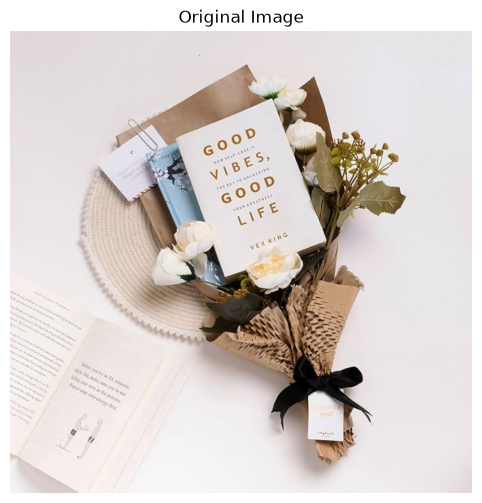

In [11]:
image = Image.open("image1.jpg").convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [12]:
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

print("Segmentation completed!")

Segmentation completed!


In [13]:
logits = outputs.logits

# Resize prediction to original image size
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

predicted_mask = upsampled_logits.argmax(dim=1)[0]

mask = predicted_mask.cpu().numpy()

print("Mask shape:", mask.shape)

Mask shape: (894, 894)


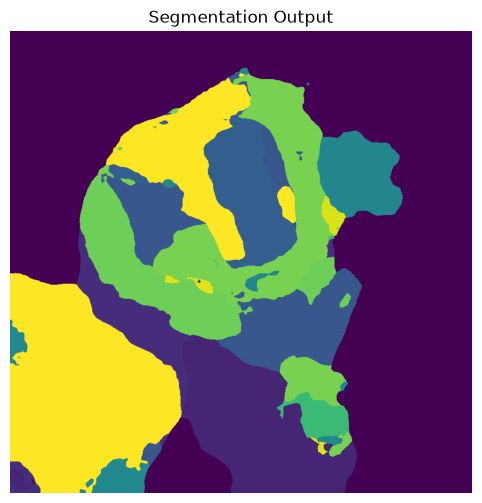

In [14]:
plt.figure(figsize=(8, 6))
plt.imshow(mask)
plt.axis("off")
plt.title("Segmentation Output")
plt.show()

In [15]:
id2label = model.config.id2label

unique_classes = np.unique(mask)

print("Detected classes:")

for class_id in unique_classes:
    print(class_id, "→", id2label[class_id])

Detected classes:
0 → wall
15 → table
19 → chair
39 → cushion
41 → box
43 → signboard
66 → flower
67 → book
98 → bottle
112 → basket
115 → bag
135 → vase
137 → tray
144 → bulletin board


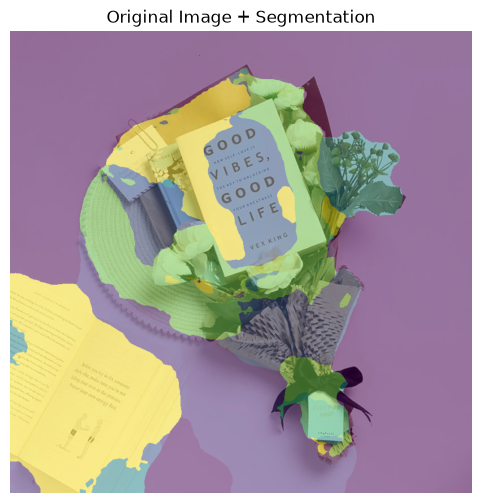

In [16]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.imshow(mask, alpha=0.5)

plt.axis("off")
plt.title("Original Image + Segmentation")
plt.show()

In [17]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\DIVYA\Task 8
['.ipynb_checkpoints', 'image1.jpg', 'task_8.ipynb']
